## Fitting a parametric function of linear shape to the data

Fitted parameters (beta): [-63651.32821769   7247.32701042   1048.56715142]


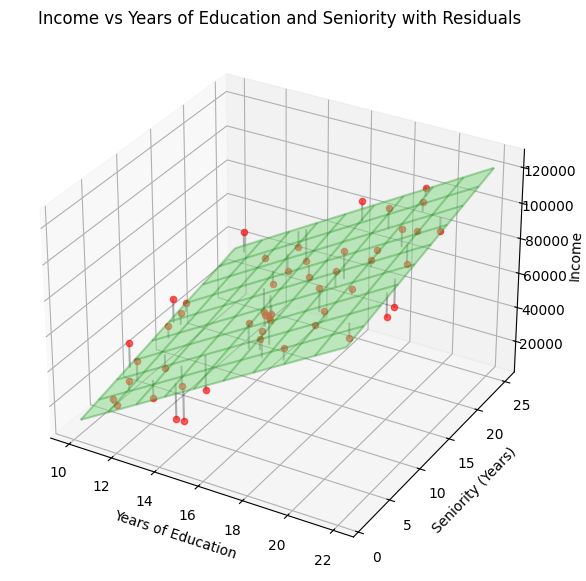

In [189]:
# Fitting a parametric function of linear shape to the data
# income = beta0 + beta1 * years_education + beta2 * seniority_years

# load csv
df = pd.read_csv("data/Income.csv")

# build design matrix X and target vector y
X = np.column_stack((np.ones(len(df)), df['years_education'], df['seniority_years']))
y = df['income'].values
# now we have Ax = b where A = X, x = beta (parameters), b = y (target)

# make a linear regression to fit the parameters 
from numpy.linalg import inv
beta_hat = inv(X.T @ X) @ X.T @ y
print("Fitted parameters (beta):", beta_hat)
# beta_hat[0]: intercept, beta_hat[1]: coef for years_education, beta_hat[2]: coef for seniority_years

# Now calculate the residuals per data point and plot them in 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
#ax.scatter(df['years_education'], df['seniority_years'], df['income'], alpha=0.6)
ax.set_xlabel('Years of Education')
ax.set_ylabel('Seniority (Years)')
ax.set_zlabel('Income')
ax.set_title('Income vs Years of Education and Seniority with Residuals')
# draw residuals
for i in range(len(df)):
    y_pred = beta_hat[0] + beta_hat[1] * df['years_education'][i] + beta_hat[2] * df['seniority_years'][i]
    ax.plot([df['years_education'][i], df['years_education'][i]], 
            [df['seniority_years'][i], df['seniority_years'][i]], 
            [df['income'][i], y_pred], 
            color='black', alpha=0.3)
    ax.scatter(df['years_education'][i], df['seniority_years'][i], df['income'][i], color='red', alpha=0.6)
   # ax.text(df['years_education'][i], df['seniority_years'][i], df['income'][i], f"{df['income'][i] - y_pred:.2f}", color='black')

# show the fitted plane
x_surf = np.linspace(10, 22, 10)
y_surf = np.linspace(1, 25, 10)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = beta_hat[0] + beta_hat[1] * x_surf + beta_hat[2] * y_surf
ax.plot_surface(x_surf, y_surf, z_surf, color='lightgreen', alpha=0.5)
ax.plot_wireframe(x_surf, y_surf, z_surf, color='green', alpha=0.3)


plt.show()

### Thin-plate Spline — kurze Erklärung und Hinweise

In der vorhergehenden Codezelle wird ein nichtparametrisches Modell vom Typ "thin-plate spline" auf die synthetischen Income-Daten angepasst. Kurz zusammengefasst:

- Was ist ein thin-plate spline?
  - Ein dünner-Plate-Spline ist eine glatte Interpolations-/Regressionsmethode, die in 2D (hier: Jahre der Ausbildung, Seniorität) eine glatte Oberfläche erzeugt.
  - Technisch wird eine Radial-Basis-Funktion (RBF) mit der Funktion `thin_plate` verwendet, die eine glatte, biegsame Oberfläche minimiert.

- Was macht die bereitgestellte Zelle?
  - Lädt `data/Income.csv` (die zuvor generierte synthetische Tabelle).
  - Versucht, `scipy.interpolate.Rbf` mit `function='thin_plate'` zu verwenden.
  - Falls SciPy nicht verfügbar ist, fällt die Zelle auf ein Beispiel mit `GaussianProcessRegressor` (GPR) als nichtparametrische Alternative zurück.
  - Die Zelle berechnet die Vorhersagen auf einem Gitter für die Visualisierung, ermittelt die Trainings-RMSE und plottet:
    - 3D-Scatter der Originaldaten und die angepasste Oberfläche
    - Histogramm der Residuen (y - y_pred)

- Wichtige Diagnosen / Interpretation
  - RMSE (Training): gibt die mittlere Abweichung auf den Trainingsdaten an — kleiner ist besser, aber bei nichtparametrischen Methoden kann Overfitting möglich sein.
  - Residuenverteilung: sollte ungefähr symmetrisch um 0 liegen; große Ausreißer oder starke Schiefe deuten auf Modellfehlanpassung oder heteroskedastische Fehler hin.
  - Oberfläche vs. Punkte: Die Oberfläche zeigt lokale nichtlineare Beziehungen — wenn sie deutlich von einer Ebene abweicht, hat das Modell nichtlineare Strukturen erfasst.

- Vorschläge für Experimente
  - Ändere die Gitterauflösung (`xi`, `yi`) für feinere Visualisierung (vorsicht: Rechenzeit). 
  - Prüfe Generalisierung: slice die Daten in Trainings-/Testset und berechne RMSE auf Testdaten.
  - Vergleiche mit parametrischem Modell (die lineare Regression aus der vorherigen Zelle) und messe Reduktion des Test-RMSE.
  - Visualisiere partielle Abhängigkeiten (z. B. mittlere Vorhersage bei fixierter Seniorität über Bildung).

Wenn du willst, führe ich die thin-plate-Zelle jetzt aus und liefere: die RMSE-Zahl, die Residuen-Histogramm-Ausgabe und die gerenderten Plots.

SciPy Rbf (thin_plate) verwendet
RMSE (Training): 0.00


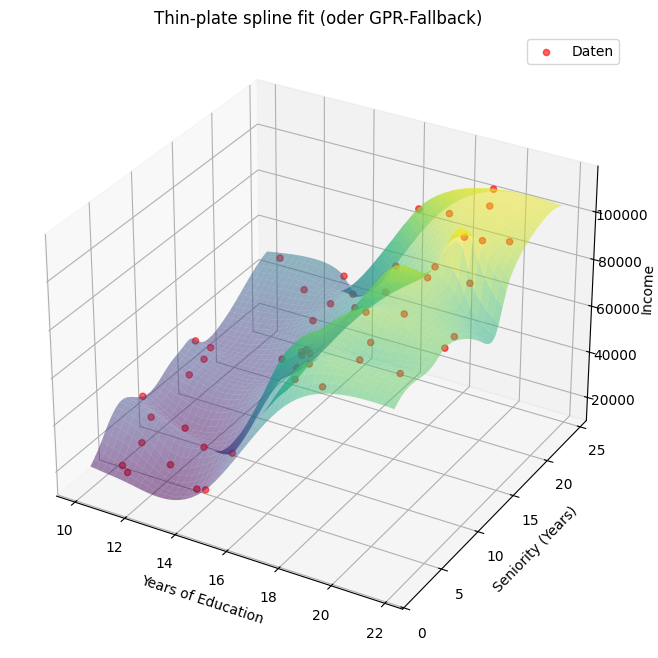

In [190]:
# Thin-plate spline fit (Python)
# Lädt data/Income.csv, passt eine thin-plate RBF (SciPy) an oder verwendet GPR als Fallback,
# berechnet RMSE und plottet die Oberfläche sowie die Residuen.

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error
import math

# Daten laden
df = pd.read_csv(Path('data') / 'Income.csv')
X1 = df['years_education'].values
X2 = df['seniority_years'].values
y = df['income'].values

# Versuch: SciPy Rbf mit thin_plate
use_scipy = False
try:
    from scipy.interpolate import Rbf
    rbf = Rbf(X1, X2, y, function='thin_plate')
    use_scipy = True
    print('SciPy Rbf (thin_plate) verwendet')
except Exception as e:
    print('SciPy Rbf nicht verfügbar, Fallback geplant:', e)

# Vorhersagen und Oberfläche berechnen
if use_scipy:
    # Gitter für Visualisierung
    xi = np.linspace(X1.min(), X1.max(), 50)
    yi = np.linspace(X2.min(), X2.max(), 50)
    XI, YI = np.meshgrid(xi, yi)
    ZI = rbf(XI, YI)
    # Vorhersagen auf Trainingsdaten
    y_pred = rbf(X1, X2)
else:
    # Fallback: Gaussian Process Regression (GPR)
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
    # Kernel: konstant * RBF + WhiteKernel (Rauschen)
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1, noise_level_bounds=(1e-5, 1e5))
    gp = GaussianProcessRegressor(kernel=kernel, random_state=0, normalize_y=True)
    X_train = np.vstack([X1, X2]).T
    gp.fit(X_train, y)
    # Grid-Vorhersage für Oberfläche
    xi = np.linspace(X1.min(), X1.max(), 50)
    yi = np.linspace(X2.min(), X2.max(), 50)
    XI, YI = np.meshgrid(xi, yi)
    XY_grid = np.vstack([XI.ravel(), YI.ravel()]).T
    ZI = gp.predict(XY_grid).reshape(XI.shape)
    y_pred = gp.predict(X_train)

# RMSE (Training)
rmse = math.sqrt(mean_squared_error(y, y_pred))
print(f'RMSE (Training): {rmse:.2f}')

# 3D-Plot: Datenpunkte und gefittete Oberfläche
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, y, color='red', alpha=0.6, label='Daten')
# Surface plot (ZI aus Gitter)
ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.5, linewidth=0, antialiased=True)
ax.set_xlabel('Years of Education')
ax.set_ylabel('Seniority (Years)')
ax.set_zlabel('Income')
ax.set_title('Thin-plate spline fit (oder GPR-Fallback)')
ax.legend()
plt.show()

## Trade off between prediction accuracy and model interpretability

If we compare the linear model and the thin plate spline model it is clear that the spline model leads to a higher accuracy as it is more flexible to represent the function f to fit the data points but on the expense of intrepretability. The linear function is better suited and some explanations on how the seniority and the educational level influence the income can be derived from this simple model. 

Why choose a restrictive model over a more complex model which fits the data better ?

- Generalization of the model for unseen examples over perfect fit
- Explainability of the predictions towards stakeholders
- To derive knowledge from data in inference tasks how play individual variables to the final result


## Supervised vs unsupervised learning

Most tasks like regression or prediction tasks follow the supervised paradigm. We have a set of observations Y for a given input vector X and like to predict Y for new X. In this case we know in our training data x and y and search for a function which describes the relationship between x and y. 

In unsupervised scenarios we have a set of observations x but no related output y. In this scenarios it is not possible to predict a variable y on x as we do not know the relationship between them as there is no f we can estimate from training data. In this scenarios we often face clustering issues where we try to detect anomalies or relationships in data to "mine" new information.

## Regression vs classification problems
Variables can be quantitive or qualitativ (also known as categoric), which means we can have a continues value to predict like in the income example or a class of a observation like in a binary classification. If our input data is quantitativ we call corresponding problems regression problems while qualitative data are classification problems.

# Assessing model accuracy

Applying different models to a problem lead to the need to validate the model accuracy to assist model selection. Therefor we need to define metrics to define the model accuracy.

## Measuring the quality of a fit

If we fit a model function f to the data X,Y with errors E we will always observe some missmatch between the fitted function values and the observations. This is due to the fact that the function tries to find a global fit to all the individual datapoints in the training data and thus can not fit each datapoint perfectly until enough free parameters are introduced. 

Typical measures for model fitness are
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Typically to validate the fitness of a selected function the input data is split into a test and train set where the train data is used to estimate the model while the testdata is used to measure the quality of the fit to unseen data. 


Fitted coefficients: [-0.97018895 -1.29925591 -0.02857194  0.56388281]
Fitted coefficients for degree 4: [-1.85625661 -1.1782961   1.01603447  0.54888791 -0.12639744]
Fitted coefficients for degree 5: [-1.78826019 -3.10838283  1.06923544  1.45191722 -0.13253837 -0.08223891]
Fitted coefficients for degree 6: [-1.85775104 -3.11377665  1.24930693  1.45343421 -0.18809374 -0.08241942
  0.00414807]
Fitted coefficients for degree 7: [-1.90961092 -4.05961085  1.44729969  2.41475025 -0.24599706 -0.30797247
  0.0080694   0.0146149 ]
Fitted coefficients for degree 8: [-2.72481941e+00 -3.77299174e+00  5.09667256e+00  1.83726918e+00
 -2.47335392e+00 -1.51564441e-01  4.27271777e-01  4.06211127e-03
 -2.40245328e-02]
Fitted coefficients for degree 9: [ -3.26594504 -10.6381692    7.86222683  14.03242107  -4.55752769
  -5.58438713   0.86928117   0.87274592  -0.05105617  -0.0451672 ]
Fitted coefficients for degree 10: [ -4.45116637  -9.40631977  16.13534764  10.95383277 -13.06729631
  -3.99321091   3.835

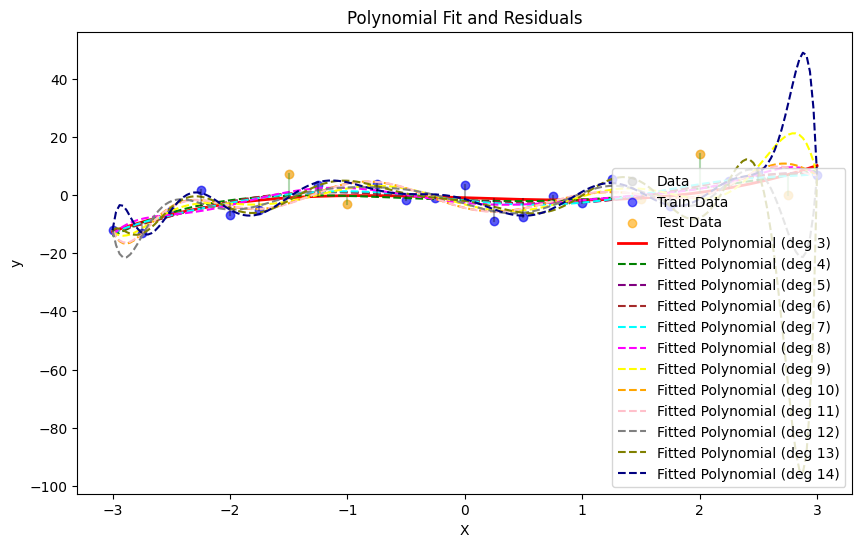

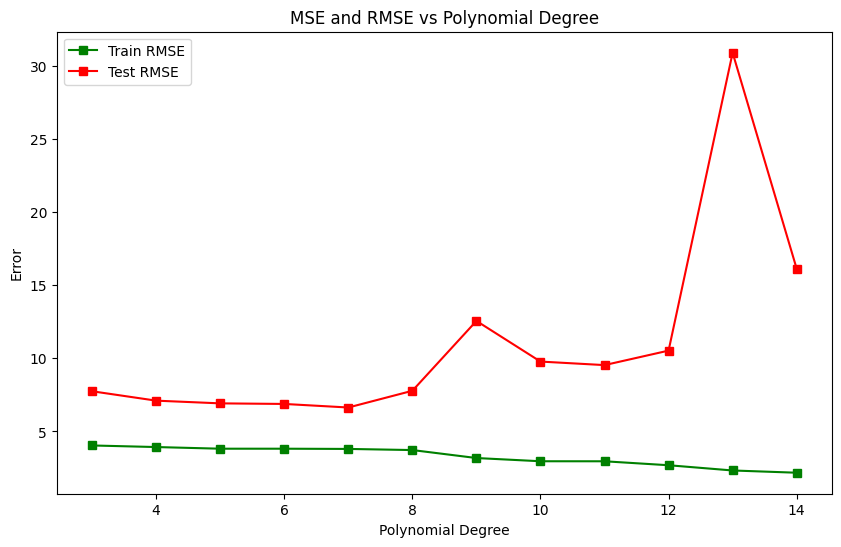

In [191]:
# Example polynomial fit and residuals plot with MSE and RMSE inc. test abd traun split

# --- IGNORE ---
import numpy as np
from matplotlib import pyplot as plt
# set seed for reproducibility#
np.random.seed(42)
# 1. generate synthetic dataset for a polynomial relationship of degree 3
# (x values between -3 and 3, y = 2 + 1.5x - 0.5x^2 + 0.3x^3 + noise)

X = np.linspace(-3, 3, 25)
y = 2 + 1.5 * X - 0.5 * X**2 + 0.3 * X**3 + np.random.normal(0, 6, size=X.shape)

# 2. split into training and test set (80% train, 20% test) manually
split_index = int(0.8 * len(X))
# randomly shuffle indices before splitting
indices = np.arange(len(X))
np.random.shuffle(indices)
train_indices = indices[:split_index]
test_indices = indices[split_index:]
X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]
# 3. fit a polynomial of degree 3 to the training data

# A = Vandermonde matrix for degree 3
A = np.vander(X_train, N=4, increasing=True)
# solve for coefficients using least squares with out lsquare
# coeffs, residuals, rank, s = np.linalg.lstsq(A, y_train, rcond=None)
coeffs = np.linalg.pinv(A) @ y_train
print("Fitted coefficients:", coeffs)
# now fit higher order polynomials of degree 4 to 6 to show how fitness changes
coeffs_dict = {}
for degree in range(4, 15):
    A_high = np.vander(X_train, N=degree+1, increasing=True)
    coeffs_high = np.linalg.pinv(A_high) @ y_train
    print(f"Fitted coefficients for degree {degree}:", coeffs_high)
    # safe the coefficients for later use during plotting
    coeffs_dict[degree] = coeffs_high
    

# 4. make predictions on training and test set
A_train = np.vander(X_train, N=4, increasing=True)
y_train_pred = A_train @ coeffs
A_test = np.vander(X_test, N=4, increasing=True)
y_test_pred = A_test @ coeffs
# 5. calculate MSE and RMSE for training and test set
mse_train = np.mean((y_train - y_train_pred)**2)
rmse_train = np.sqrt(mse_train)
mse_test = np.mean((y_test - y_test_pred)**2)
rmse_test = np.sqrt(mse_test)
print(f"Training MSE: {mse_train:.2f}, RMSE: {rmse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}")   
# 6. plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='lightgray', label='Data', alpha=0.6)
plt.scatter(X_train, y_train, color='blue', label='Train Data', alpha=0.6)
plt.scatter(X_test, y_test, color='orange', label='Test Data', alpha=0.6)
# plot fitted polynomial curve
X_fit = np.linspace(-3, 3, 200)
A_fit = np.vander(X_fit, N=4, increasing=True)
y_fit = A_fit @ coeffs
plt.plot(X_fit, y_fit, color='red', label='Fitted Polynomial (deg 3)', linewidth=2)
# now plot higher degree polynomials
colors = ['green', 'purple', 'brown', 'cyan', 'magenta', 'yellow', 'orange', 'pink', 'gray', 'olive', 'navy']
for i, degree in enumerate(range(4, 15)):
    A_fit_high = np.vander(X_fit, N=degree+1, increasing=True)
    y_fit_high = A_fit_high @ coeffs_dict[degree]
    plt.plot(X_fit, y_fit_high, color=colors[i], label=f'Fitted Polynomial (deg {degree})', linewidth=1.5, linestyle='--')
    
# plot residuals for training data
for i in range(len(X_train)):
    plt.plot([X_train[i], X_train[i]], [y_train[i], y_train_pred[i]], color='black', alpha=0.3) 
# plot residuals for test data
for i in range(len(X_test)):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_test_pred[i]], color='green', alpha=0.3) 
    
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Fit and Residuals')
plt.legend()
plt.show()

# now plot the MSE and RMSE values for training and test set as line plot for the different polynomial degrees
degrees = list(range(3, 15))
mse_train_list = []
rmse_train_list = []
mse_test_list = []
rmse_test_list = []
for degree in degrees:
    A_train_deg = np.vander(X_train, N=degree+1, increasing=True)
    coeffs_deg = np.linalg.pinv(A_train_deg) @ y_train
    y_train_pred_deg = A_train_deg @ coeffs_deg
    mse_train_deg = np.mean((y_train - y_train_pred_deg)**2)
    rmse_train_deg = np.sqrt(mse_train_deg)
    mse_train_list.append(mse_train_deg)
    rmse_train_list.append(rmse_train_deg)
    
    A_test_deg = np.vander(X_test, N=degree+1, increasing=True)
    y_test_pred_deg = A_test_deg @ coeffs_deg
    mse_test_deg = np.mean((y_test - y_test_pred_deg)**2)
    rmse_test_deg = np.sqrt(mse_test_deg)
    mse_test_list.append(mse_test_deg)
    rmse_test_list.append(rmse_test_deg)
plt.figure(figsize=(10, 6))
#plt.plot(degrees, mse_train_list, marker='o', label='Train MSE', color='blue')
#plt.plot(degrees, mse_test_list, marker='o', label='Test MSE', color='orange')
plt.plot(degrees, rmse_train_list, marker='s', label='Train RMSE', color='green')
plt.plot(degrees, rmse_test_list, marker='s', label='Test RMSE', color='red')
plt.xlabel('Polynomial Degree')
plt.ylabel('Error')
plt.title('MSE and RMSE vs Polynomial Degree')
plt.legend()
plt.show()


## The bias variance tradeoff

From the experiment we can see how the MSE and RMSE error decreases with increase of the model flexibility or number of parameters. On the same time the model fitting increases and the polynomial fits start to oscillate around the train values which were provided during the training. On the same time the test rmse is rising as the model is focusing now to much on the train data and try to make the function perfect fitting for the train data while ignoring the underfitting pattern or function (f) and gets influenced by the errors E in the train data. 

Therefore the train MSE can be quite small while the test MSE keeps larger or even grows. 

It can be shown that the expected test MSE for a given Value x0 can always be decomposed into a sum of three fundamental quantities: The variance $\hat f(x_0)$, the squared bias of $\hat f(x_0)$ and the variance of the error term.

Thus, the expected test MSE can be written as

$$
\boxed{
\mathrm{MSE}(x_0)
=
\underbrace{\mathrm{Bias}^2(\hat f(x_0))}_{(f(x_0)-\mathbb{E}[\hat f(x_0)])^2}
+
\underbrace{\mathrm{Var}(\hat f(x_0))}_{\mathbb{E}[(\hat f(x_0)-\mathbb{E}[\hat f(x_0)])^2]}
+
\underbrace{\sigma^2}_{\text{irreducible error}}
}
$$

Therefor the goal of a statistical learning method is to minimize both the variance and the bias while the irreducible error cant be resolved by a model and will remain as inaccuracy.

---

# Bias–Variance Tradeoff (Derivation of the Test MSE Decomposition)

These notes provide a formal derivation of the bias–variance decomposition of the
expected test mean squared error (MSE) as stated in *Introduction to Statistical Learning*
(Chapter 2.2.2). The derivation is general and is subsequently interpreted using the
example of polynomial regression.

---

## 1. Data-generating model

We consider the regression model

$$
Y = f(X) + \varepsilon,
$$

with

$$
\mathbb{E}[\varepsilon] = 0,
\qquad
\mathrm{Var}(\varepsilon) = \sigma^2,
$$

where $\varepsilon$ is independent of $X$.

For a fixed test point $x_0$,

$$
Y_0 = f(x_0) + \varepsilon_0.
$$

Let $\hat f$ denote a predictor estimated from a random training sample.

---

## 2. Expected test error at a fixed point $x_0$

The expected test error (mean squared error) is defined as

$$
\mathrm{MSE}(x_0)
=
\mathbb{E}\big[(Y_0 - \hat f(x_0))^2 \mid X_0 = x_0\big].
$$

The expectation is taken over both the randomness in the training data and the noise
term $\varepsilon_0$.

---

## 3. Algebraic decomposition

Substituting $Y_0 = f(x_0) + \varepsilon_0$,

$$
\mathbb{E}\big[(f(x_0) + \varepsilon_0 - \hat f(x_0))^2\big].
$$

Add and subtract $\mathbb{E}[\hat f(x_0)]$:

$$
=
\mathbb{E}\Big[
\big(
f(x_0) - \mathbb{E}[\hat f(x_0)]
+ \mathbb{E}[\hat f(x_0)] - \hat f(x_0)
+ \varepsilon_0
\big)^2
\Big].
$$

After expanding the square, all cross terms vanish because

$$
\mathbb{E}[\varepsilon_0] = 0,
\qquad
\mathbb{E}[\hat f(x_0) - \mathbb{E}[\hat f(x_0)]] = 0,
$$

and $\varepsilon_0$ is independent of $\hat f(x_0)$.

This yields:

$$
\mathrm{MSE}(x_0)
=
(f(x_0) - \mathbb{E}[\hat f(x_0)])^2
+
\mathbb{E}\big[(\hat f(x_0) - \mathbb{E}[\hat f(x_0)])^2\big]
+
\mathbb{E}[\varepsilon_0^2].
$$

---

## 4. Bias–variance decomposition

Thus, the expected test MSE can be written as

$$
\boxed{
\mathrm{MSE}(x_0)
=
\underbrace{\mathrm{Bias}^2(\hat f(x_0))}_{(f(x_0)-\mathbb{E}[\hat f(x_0)])^2}
+
\underbrace{\mathrm{Var}(\hat f(x_0))}_{\mathbb{E}[(\hat f(x_0)-\mathbb{E}[\hat f(x_0)])^2]}
+
\underbrace{\sigma^2}_{\text{irreducible error}}
}
$$

---

## 5. Example: Polynomial regression

### Model

True regression function:

$$
f(x) = \sin(x)
$$

Observed data:

$$
Y = \sin(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\sigma^2)
$$

We approximate $f$ using a polynomial of degree $d$:

$$
\hat f_d(x) = \sum_{k=0}^{d} \hat\beta_k x^k.
$$

---

## 6. Bias in the polynomial example

The bias at the point $x_0$ is

$$
\mathrm{Bias}(\hat f_d(x_0))
=
\mathbb{E}[\hat f_d(x_0)] - f(x_0).
$$

Interpretation:
- Small polynomial degree $d$: restricted function space → high bias  
- Large polynomial degree $d$: better approximation of $f$ → low bias  

Formally, $\mathbb{E}[\hat f_d]$ is the orthogonal projection of $f$ onto the space
of polynomials of degree at most $d$.

---

## 7. Variance in the polynomial example

The variance is defined as

$$
\mathrm{Var}(\hat f_d(x_0))
=
\mathrm{Var}\left(\sum_{k=0}^{d} \hat\beta_k x_0^k\right).
$$

For linear regression, this can be written explicitly as

$$
\mathrm{Var}(\hat f_d(x_0))
=
\sigma^2\, x_0^\top (X^\top X)^{-1} x_0,
$$

where $X$ denotes the design matrix.

Interpretation:
- Small degree $d$: few parameters → low variance  
- Large degree $d$: many parameters → high variance  

---

## 8. Irreducible error

The term

$$
\mathbb{E}[\varepsilon_0^2] = \sigma^2
$$

is independent of the model choice and cannot be reduced by increasing model
complexity or sample size.

---

## 9. Key takeaway

The bias–variance decomposition holds for **any regression method** when squared
error loss is used:

$$
\text{Test error} = \text{Bias}^2 + \text{Variance} + \text{Noise}.
$$

The bias–variance tradeoff captures the fundamental tension between model
complexity and generalization performance.


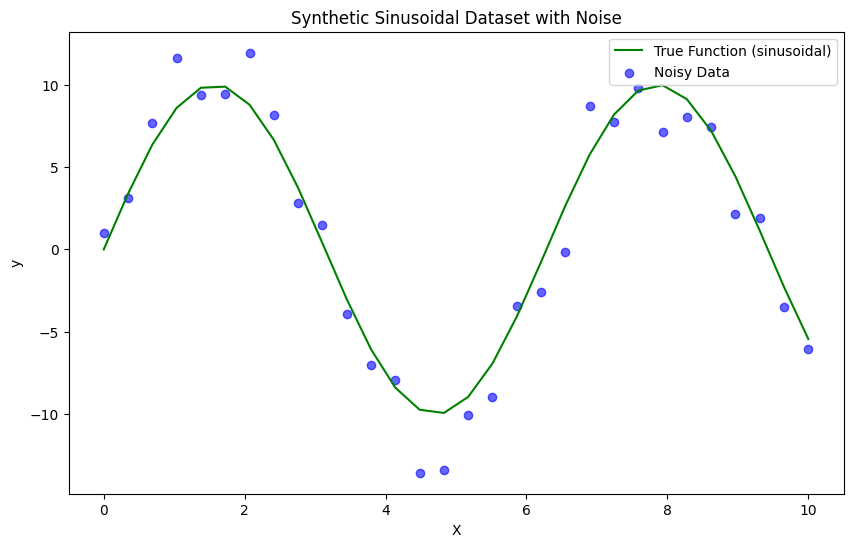

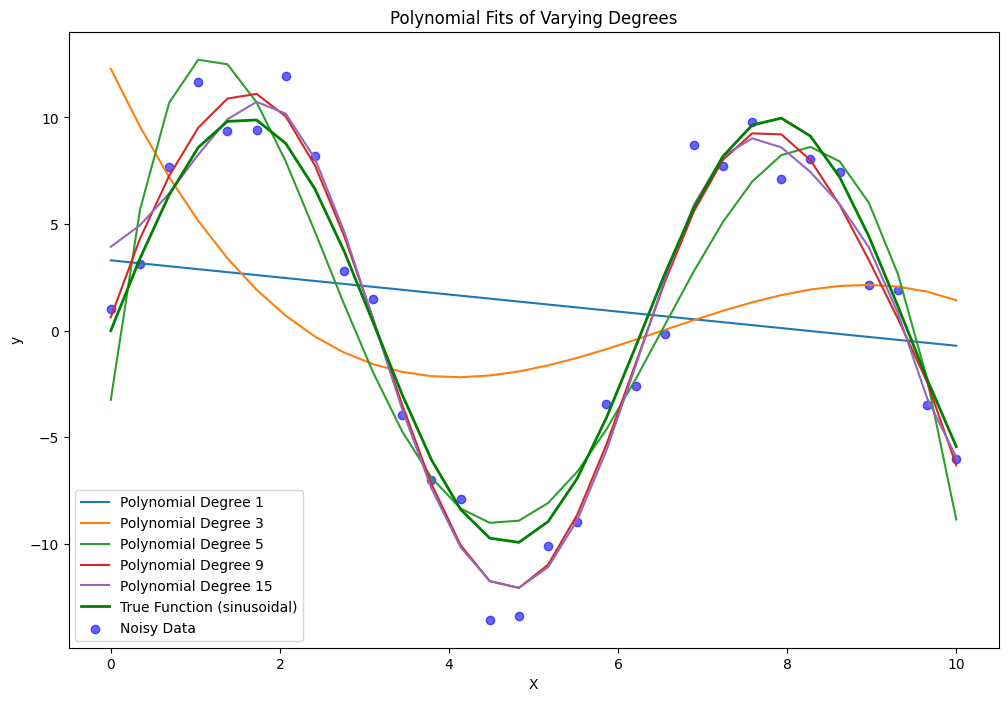

In [192]:
# code example for generating a synthetic dataset with a sinusoidal relationship plus noise
# and showing the variance and bias trade-off with polynomial fitting


import numpy as np
import matplotlib.pyplot as plt
# set seed for reproducibility
np.random.seed(42)
# generate synthetic dataset
X = np.linspace(0, 10, 30)
y_true = np.sin(X) * 10  # true underlying function
y = y_true + np.random.normal(0, 2, size=X.shape)  # add noise
# plot the true function and noisy data
plt.figure(figsize=(10, 6))
plt.plot(X, y_true, label='True Function (sinusoidal)', color='green')
plt.scatter(X, y, label='Noisy Data', color='blue', alpha=0.6)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Sinusoidal Dataset with Noise')
plt.legend()
plt.show()

# fit polynomials of varying degrees and show bias-variance trade-off
degrees = [1, 3, 5, 9, 15]
plt.figure(figsize=(12, 8))
for degree in degrees:
    A = np.vander(X, N=degree+1, increasing=True)
    coeffs = np.linalg.pinv(A) @ y
    y_fit = A @ coeffs
    plt.plot(X, y_fit, label=f'Polynomial Degree {degree}')
# plot the true function and noisy data
plt.plot(X, y_true, label='True Function (sinusoidal)', color='green', linewidth=2)
plt.scatter(X, y, label='Noisy Data', color='blue', alpha=0.6)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Fits of Varying Degrees')
plt.legend()
plt.show()



## Summary on bias and variance

**Bias** quantifies the systematic error introduced by approximating the true function $$f(x)$$ with a restricted or overly simple model. It is defined as the difference between the true function and the expected model prediction, $$f(x) - \mathbb{E}[\hat f(x)]$$, and reflects limitations of the model class rather than randomness in the training data.

**Variance** measures how sensitive the learned model $$\hat f(x)$$ is to the specific training data used. It captures how much the predictions $$\hat f(x)$$ would vary if the model were trained on different random training sets (or subsamples) drawn from the same data-generating distribution, with high variance indicating strong dependence on the sampled data.



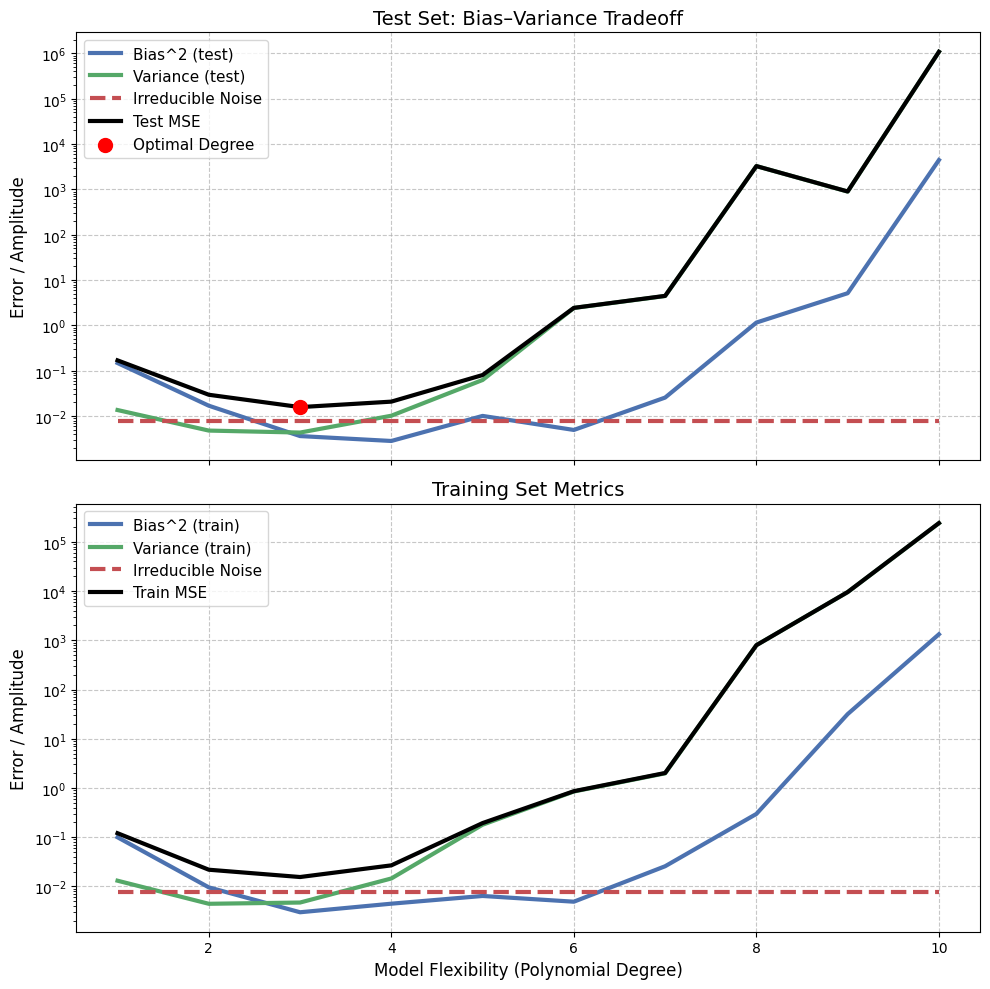

In [193]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Datensatz: Wahre Funktion Polynom 3. Ordnung ---
N = 30
X = np.linspace(-1, 1, N)
y_true = 0.5*X**3 - X**2 + X   # 3. Ordnung Polynom
noise_sigma = 0.1
y = y_true + np.random.normal(0, noise_sigma, size=X.shape)
degrees = np.arange(1, 11)  # Polynomialgrade 1 bis 10

# train/test split
train_frac = 0.7
idx = np.arange(N)
np.random.shuffle(idx)
n_train = int(train_frac * N)
n_test = N - n_train
test_idx = idx[:n_test]
train_pool = idx[n_test:]
fixed_train_idx = train_pool[:n_train]

# bootstrap params
n_repeats = 500
est_noise_var = np.var(y - y_true)

# containers
bias2_test, var_test, mse_test = [], [], []
bias2_train, var_train, mse_train = [], [], []

# --- Simulation über Polynomialgrade ---
for deg in degrees:
    preds_test = np.zeros((n_repeats, n_test))
    preds_train = np.zeros((n_repeats, n_train))
    
    for r in range(n_repeats):
        samp_idx = np.random.choice(train_pool, size=n_train, replace=True)
        X_train, y_train = X[samp_idx], y[samp_idx]
        
        # Polynomfit
        A = np.vander(X_train, N=deg+1, increasing=True)
        coeffs = np.linalg.pinv(A) @ y_train
        
        # Testvorhersage
        A_test = np.vander(X[test_idx], N=deg+1, increasing=True)
        preds_test[r, :] = A_test @ coeffs
        
        # Trainingsvorhersage (fixiertes Trainingsset)
        A_train_eval = np.vander(X[fixed_train_idx], N=deg+1, increasing=True)
        preds_train[r, :] = A_train_eval @ coeffs
    
    # Test set
    mean_pred_test = preds_test.mean(axis=0)
    var_pred_test = preds_test.var(axis=0, ddof=0)
    bias2_test.append(np.mean((mean_pred_test - y_true[test_idx])**2))
    var_test.append(np.mean(var_pred_test))
    mse_test.append(bias2_test[-1] + var_test[-1] + est_noise_var)
    
    # Train set
    mean_pred_train = preds_train.mean(axis=0)
    var_pred_train = preds_train.var(axis=0, ddof=0)
    bias2_train.append(np.mean((mean_pred_train - y_true[fixed_train_idx])**2))
    var_train.append(np.mean(var_pred_train))
    mse_train.append(bias2_train[-1] + var_train[-1] + est_noise_var)

# --- Plots: zwei Subplots ---
fig, axs = plt.subplots(2, 1, figsize=(10,10), sharex=True)

# --- Testset (oben) ---
axs[0].semilogy(degrees, bias2_test, color='#4c72b0', lw=3, label='Bias^2 (test)')
axs[0].semilogy(degrees, var_test, color='#55a868', lw=3, label='Variance (test)')
axs[0].semilogy(degrees, [est_noise_var]*len(degrees), color='#c44e52', lw=3, linestyle='--', label='Irreducible Noise')
axs[0].semilogy(degrees, mse_test, color='black', lw=3, label='Test MSE')

# Minimum markieren
min_idx = np.argmin(mse_test)
axs[0].scatter(degrees[min_idx], mse_test[min_idx], color='red', s=100, zorder=5, label='Optimal Degree')

axs[0].set_ylabel('Error / Amplitude', fontsize=12)
axs[0].set_title('Test Set: Bias–Variance Tradeoff', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].legend(fontsize=11)

# --- Trainingsset (unten) ---
axs[1].semilogy(degrees, bias2_train, color='#4c72b0', lw=3, label='Bias^2 (train)')
axs[1].semilogy(degrees, var_train, color='#55a868', lw=3, label='Variance (train)')
axs[1].semilogy(degrees, [est_noise_var]*len(degrees), color='#c44e52', lw=3, linestyle='--', label='Irreducible Noise')
axs[1].semilogy(degrees, mse_train, color='black', lw=3, label='Train MSE')

axs[1].set_xlabel('Model Flexibility (Polynomial Degree)', fontsize=12)
axs[1].set_ylabel('Error / Amplitude', fontsize=12)
axs[1].set_title('Training Set Metrics', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].legend(fontsize=11)

plt.tight_layout()
plt.show()


> ##  Bias–Variance Tradeoff
> 
> **Ziel:** Minimierung des Testfehlers (MSE) durch optimale Modellflexibilität.
> 
> **Bias:** Systematischer Fehler → wie stark weicht die erwartete Vorhersage vom wahren Modell ab. Hoher Bias → Underfitting → Test-MSE hoch.
> 
> **Variance:** Sensitivität des Modells gegenüber verschiedenen Trainingsdaten (oder Bootstrap-Stichproben). Hohe Varianz → Overfitting → Test-MSE steigt.
> 
> **Irreduzibler Fehler:** Teil des Fehlers durch Rauschen, nicht reduzierbar.
> 
> **Tradeoff:** Niedrige Flexibilität → hoher Bias, niedrige Varianz. Hohe Flexibilität → niedriger Bias, hohe Varianz. Optimales Modell minimiert Bias² + Varianz + irreduziblen Fehler → Test-MSE Minimum.
> 
> **Visualisierung:** Klassische „Badewannen-Kurve“ zeigt fallenden Bias², steigende Varianz und Test-MSE Minimum.


## The classification setting

Previously we mainly focused on model accuracy of regression task and omitted classification tasks and how to measure there the model accuracy. In this case y is no longer quantitative but qualitative or categoric. Therefor the metric of successful classification needs to be redefined. 

The most common approach is the error rate, which describes how often the model predicts the wrong class relative to all predictions, leading to 

$$
Ave(I(y_0 \neq \hat y_0))
$$
as test error function. A good classifier minimizes this error function.
## The bayes classifier

The bayes classifier is the best classifier to minimize the above error function by assigning to each observation X to the most likely class y. Or in other words we should find a classifier which maximizes the probability
$$
P_r(Y=j|X=x_0)
$$.

$P_r$ is a conditional propability which meaning that it is the propability Y=j given the observation $x_0$.





## The Bayes Classifier: Optimality Proof

### 1. General Setting (Any number of classes)

Let $Y$ be a categorical response with possible classes $\{1, \dots, K\}$, and let $\hat{Y}(x_0)$ denote the predicted class for an observation $X=x_0$.  

The **0-1 loss** (classification error) is defined as:

$$
L(\hat{Y}(x_0), Y) = I(\hat{Y}(x_0) \neq Y)
$$

where $I(\cdot)$ is the indicator function. The **conditional expected error** at $x_0$ is:

$$
\mathbb{E}[L(\hat{Y}(x_0), Y) \mid X=x_0] 
= \sum_{j=1}^K I(\hat{Y}(x_0) \neq j) \, P(Y=j \mid X=x_0)
= 1 - P(Y=\hat{Y}(x_0) \mid X=x_0)
$$

To **minimize the conditional error**, we must choose $\hat{Y}(x_0)$ that **maximizes** $P(Y=j \mid X=x_0)$:

$$
\hat{Y}_{\text{Bayes}}(x_0) = \arg\max_{j \in \{1,\dots,K\}} P(Y=j \mid X=x_0)
$$

Since this minimizes the conditional error for each $x_0$, it also minimizes the **overall expected test error**:

$$
\mathbb{E}[L(\hat{Y}(X), Y)] = \mathbb{E}_X[\mathbb{E}[L(\hat{Y}(X), Y) \mid X]].
$$

---

### 2. Special Case: Binary Classification

Suppose $Y \in \{0,1\}$, and let:

$$
p(x_0) = P(Y=1 \mid X=x_0)
$$

Then the conditional expected error for predicting class $\hat{Y}(x_0) \in \{0,1\}$ is:

- If $\hat{Y}(x_0) = 1$:

$$
\mathbb{E}[L(\hat{Y},Y)\mid X=x_0] = P(Y=0 \mid X=x_0) = 1 - p(x_0)
$$

- If $\hat{Y}(x_0) = 0$:

$$
\mathbb{E}[L(\hat{Y},Y)\mid X=x_0] = P(Y=1 \mid X=x_0) = p(x_0)
$$

To minimize the conditional error, choose:

$$
\hat{Y}_{\text{Bayes}}(x_0) =
\begin{cases}
1 & \text{if } p(x_0) > 0.5 \\
0 & \text{if } p(x_0) \le 0.5
\end{cases}
$$

This is exactly the **majority class decision** given the conditional probability. By minimizing the conditional error for each $x_0$, the **overall expected test error** is also minimized.

---

### Summary

- **Bayes Classifier** predicts the class with the highest conditional probability $P(Y=j\mid X=x_0)$.  
- It **minimizes the expected 0-1 loss** (classification error) for any number of classes.  
- In **binary classification**, this reduces to predicting $1$ if $p(x_0) > 0.5$ and $0$ otherwise.


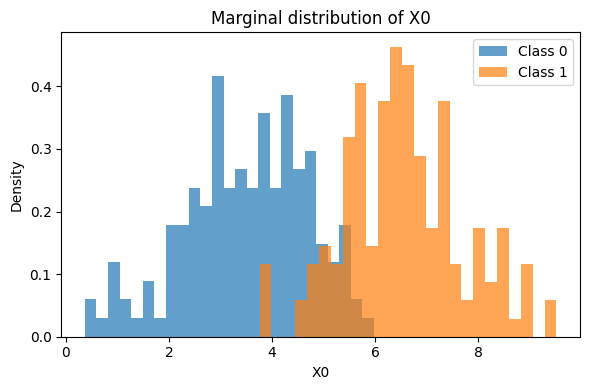

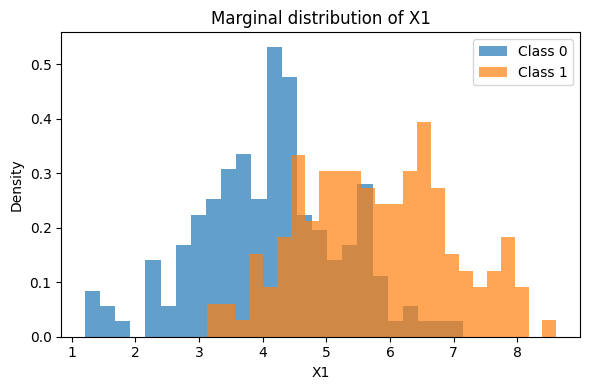

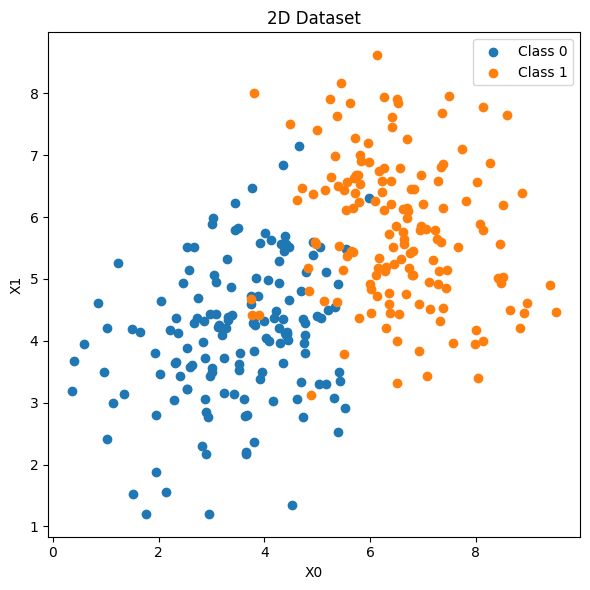

Classification accuracy: 0.943


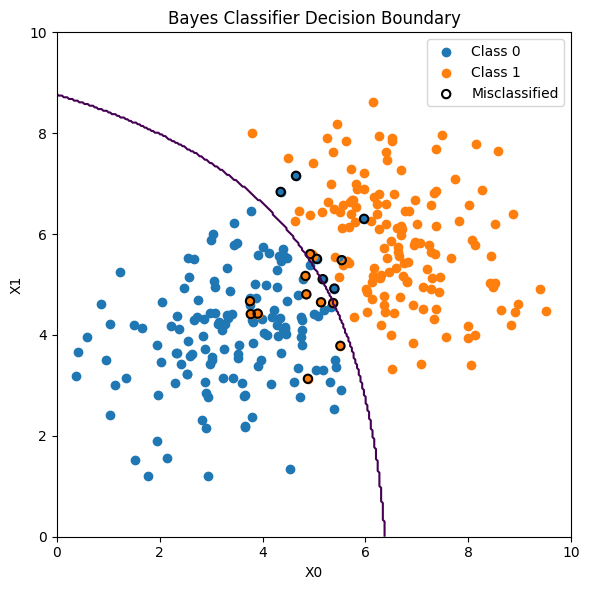

In [194]:
# ============================================================
# Bayes Classifier Demo (2D, Binary Classification)
# ============================================================
# This notebook cell:
# 1) Generates a 2D dataset (X0, X1 in [0,10]) with two classes
# 2) Shows marginal class distributions
# 3) Visualizes the 2D data
# 4) Builds a Gaussian Bayes classifier step by step
# 5) Applies it to the data
# 6) Plots the Bayes decision boundary and misclassified points
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Generate synthetic dataset
# ------------------------------------------------------------
np.random.seed(0)

n_per_class = 150

# Class 0 parameters
mu0 = np.array([3.5, 4.0])
Sigma0 = np.array([[1.5, 0.3],
                   [0.3, 1.2]])

# Class 1 parameters
mu1 = np.array([6.5, 6.0])
Sigma1 = np.array([[1.4, -0.2],
                   [-0.2, 1.3]])

X0 = np.random.multivariate_normal(mu0, Sigma0, n_per_class)
X1 = np.random.multivariate_normal(mu1, Sigma1, n_per_class)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# Clip features to [0,10] for clean visualization
X = np.clip(X, 0, 10)

# ------------------------------------------------------------
# 2. Marginal class distributions (X0 and X1)
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(X0[:,0], bins=25, density=True, alpha=0.7, label="Class 0")
plt.hist(X1[:,0], bins=25, density=True, alpha=0.7, label="Class 1")
plt.xlabel("X0")
plt.ylabel("Density")
plt.title("Marginal distribution of X0")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(X0[:,1], bins=25, density=True, alpha=0.7, label="Class 0")
plt.hist(X1[:,1], bins=25, density=True, alpha=0.7, label="Class 1")
plt.xlabel("X1")
plt.ylabel("Density")
plt.title("Marginal distribution of X1")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. 2D data visualization
# ------------------------------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")
plt.xlabel("X0")
plt.ylabel("X1")
plt.title("2D Dataset")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Build the Gaussian Bayes classifier
# ------------------------------------------------------------

# Class priors
pi0 = np.mean(y == 0)
pi1 = np.mean(y == 1)

# Class means
mu0_hat = X[y == 0].mean(axis=0)
mu1_hat = X[y == 1].mean(axis=0)

# Class covariance matrices
Sigma0_hat = np.cov(X[y == 0].T)
Sigma1_hat = np.cov(X[y == 1].T)

def gaussian_pdf(x, mu, Sigma):
    """Multivariate Gaussian density."""
    d = len(mu)
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm_const = 1.0 / np.sqrt((2 * np.pi)**d * det)
    diff = x - mu
    return norm_const * np.exp(-0.5 * diff @ inv @ diff.T)

def bayes_predict(X):
    """Bayes classifier."""
    preds = []
    for x in X:
        p0 = pi0 * gaussian_pdf(x, mu0_hat, Sigma0_hat)
        p1 = pi1 * gaussian_pdf(x, mu1_hat, Sigma1_hat)
        preds.append(1 if p1 > p0 else 0)
    return np.array(preds)

# ------------------------------------------------------------
# 5. Apply classifier to data
# ------------------------------------------------------------
y_pred = bayes_predict(X)
misclassified = y_pred != y

accuracy = np.mean(y_pred == y)
print(f"Classification accuracy: {accuracy:.3f}")

# ------------------------------------------------------------
# 6. Decision boundary visualization
# ------------------------------------------------------------
xx, yy = np.meshgrid(
    np.linspace(0, 10, 300),
    np.linspace(0, 10, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_pred = bayes_predict(grid).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contour(xx, yy, grid_pred, levels=[0.5])
plt.scatter(X[y==0,0], X[y==0,1], label="Class 0")
plt.scatter(X[y==1,0], X[y==1,1], label="Class 1")
plt.scatter(
    X[misclassified,0], X[misclassified,1],
    facecolors="none", edgecolors="k", linewidths=1.5,
    label="Misclassified"
)
plt.xlabel("X0")
plt.ylabel("X1")
plt.title("Bayes Classifier Decision Boundary")
plt.legend()
plt.tight_layout()
plt.show()


Also we are using the bayes classifier to minimize the error of false classification, no perfect separation between the two classes is obtained. This remaining error
$$
1-E(max_j P_r(Y=j|X))
$$

is called the bayes error rate and is analogue to the non reducible error in the regression task. 

Caution, the bayes error rate is only the correct measurement of the non reducible error if the assumptions on the underlying distribution is correct. The following example shows what happens if we are not using the correct underlying distribution and thus a wrong formulation of the PDF (Probability density function).

Test error rates
QDA  (high flexibility): 0.108
LDA  (medium):           0.113
GNB  (low flexibility):  0.113


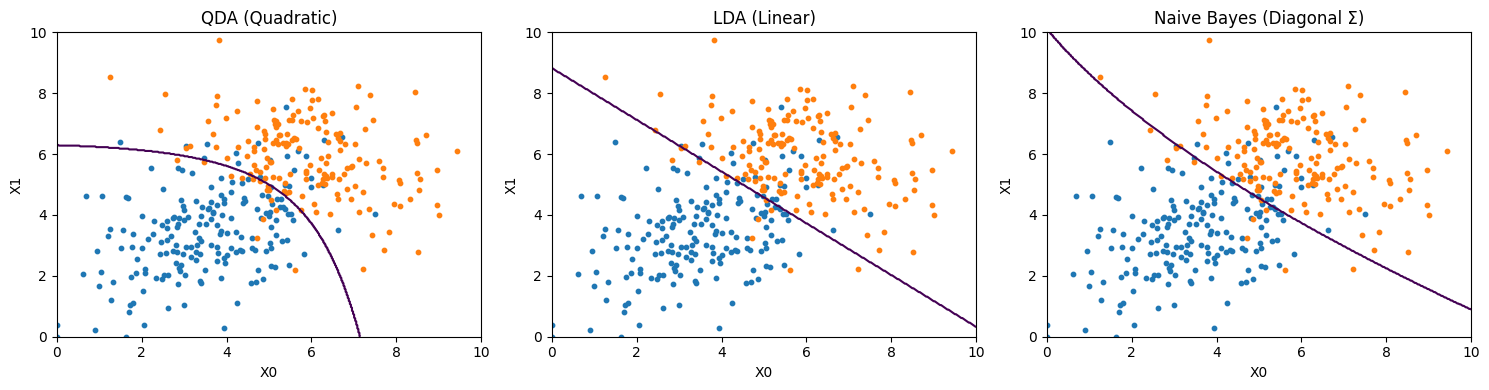

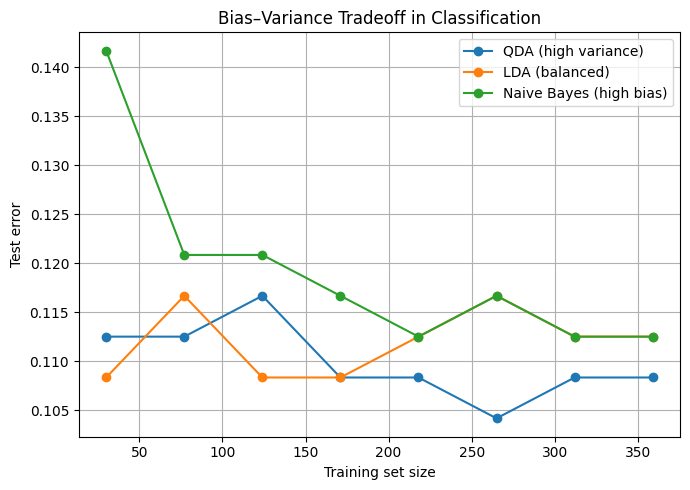

In [195]:
# ============================================================
# Bias–Variance Tradeoff in Classification (ISL-style demo)
# Stand-alone notebook cell
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss

# ------------------------------------------------------------
# 1) Synthetic 2D dataset (Gaussian, overlapping classes)
# ------------------------------------------------------------
np.random.seed(2)
n = 600

mu0 = np.array([3.5, 3.5])
Sigma0 = np.array([[2.0, 0.8],
                   [0.8, 2.0]])

mu1 = np.array([6.0, 6.0])
Sigma1 = np.array([[2.0, -0.6],
                   [-0.6, 2.0]])

X0 = np.random.multivariate_normal(mu0, Sigma0, n // 2)
X1 = np.random.multivariate_normal(mu1, Sigma1, n // 2)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n // 2), np.ones(n // 2)])

X = np.clip(X, 0, 10)

# ------------------------------------------------------------
# 2) Train / test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=0
)

# ------------------------------------------------------------
# 3) Fit Bayes classifiers
# ------------------------------------------------------------
qda = QuadraticDiscriminantAnalysis()
lda = LinearDiscriminantAnalysis()
gnb = GaussianNB()

qda.fit(X_train, y_train)
lda.fit(X_train, y_train)
gnb.fit(X_train, y_train)

# ------------------------------------------------------------
# 4) Test error comparison
# ------------------------------------------------------------
print("Test error rates")
print(f"QDA  (high flexibility): {zero_one_loss(y_test, qda.predict(X_test)):.3f}")
print(f"LDA  (medium):           {zero_one_loss(y_test, lda.predict(X_test)):.3f}")
print(f"GNB  (low flexibility):  {zero_one_loss(y_test, gnb.predict(X_test)):.3f}")

# ------------------------------------------------------------
# 5) Decision boundary plots
# ------------------------------------------------------------
xx, yy = np.meshgrid(
    np.linspace(0, 10, 400),
    np.linspace(0, 10, 400)
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_qda = qda.predict(grid).reshape(xx.shape)
Z_lda = lda.predict(grid).reshape(xx.shape)
Z_gnb = gnb.predict(grid).reshape(xx.shape)

plt.figure(figsize=(15,4))

models = [(Z_qda, "QDA (Quadratic)"),
          (Z_lda, "LDA (Linear)"),
          (Z_gnb, "Naive Bayes (Diagonal Σ)")]

for i, (Z, title) in enumerate(models, 1):
    plt.subplot(1,3,i)
    plt.contour(xx, yy, Z, levels=[0.5])
    plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], s=10)
    plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], s=10)
    plt.title(title)
    plt.xlabel("X0")
    plt.ylabel("X1")
    plt.xlim(0,10)
    plt.ylim(0,10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Bias–Variance intuition via training set size
# ------------------------------------------------------------
n_train_total = len(X_train)
train_sizes = np.linspace(30, n_train_total - 1, 8, dtype=int)

err_qda, err_lda, err_gnb = [], [], []

for m in train_sizes:
    idx = np.random.choice(n_train_total, size=m, replace=False)
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    qda.fit(X_sub, y_sub)
    lda.fit(X_sub, y_sub)
    gnb.fit(X_sub, y_sub)

    err_qda.append(zero_one_loss(y_test, qda.predict(X_test)))
    err_lda.append(zero_one_loss(y_test, lda.predict(X_test)))
    err_gnb.append(zero_one_loss(y_test, gnb.predict(X_test)))

plt.figure(figsize=(7,5))
plt.plot(train_sizes, err_qda, marker='o', label="QDA (high variance)")
plt.plot(train_sizes, err_lda, marker='o', label="LDA (balanced)")
plt.plot(train_sizes, err_gnb, marker='o', label="Naive Bayes (high bias)")
plt.xlabel("Training set size")
plt.ylabel("Test error")
plt.title("Bias–Variance Tradeoff in Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Approximate theoretical Bayes error: 0.112
QDA error (estimated from data):     0.114
Uniform Bayes (misspecified) error:  0.428


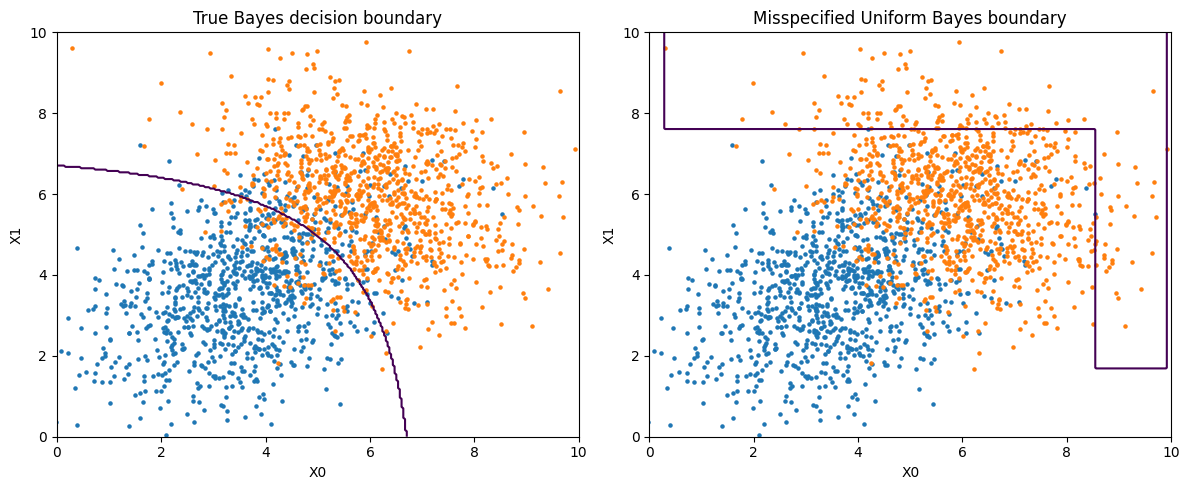

In [196]:
# ============================================================
# Theoretical Bayes Error + Model Misspecification Demo
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import zero_one_loss

np.random.seed(3)

# ------------------------------------------------------------
# 1) Ground-truth data-generating process
# ------------------------------------------------------------
n = 2000

mu0 = np.array([3.5, 3.5])
Sigma0 = np.array([[2.0, 0.8],
                   [0.8, 2.0]])

mu1 = np.array([6.0, 6.0])
Sigma1 = np.array([[2.0, -0.6],
                   [-0.6, 2.0]])

X0 = np.random.multivariate_normal(mu0, Sigma0, n // 2)
X1 = np.random.multivariate_normal(mu1, Sigma1, n // 2)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n // 2), np.ones(n // 2)])

priors = [0.5, 0.5]

# ------------------------------------------------------------
# 2) True Bayes classifier (known distributions)
# ------------------------------------------------------------
def true_bayes_classifier(X):
    p0 = multivariate_normal.pdf(X, mu0, Sigma0) * priors[0]
    p1 = multivariate_normal.pdf(X, mu1, Sigma1) * priors[1]
    return (p1 > p0).astype(int)

y_bayes = true_bayes_classifier(X)
bayes_error = np.mean(y_bayes != y)

print(f"Approximate theoretical Bayes error: {bayes_error:.3f}")

# ------------------------------------------------------------
# 3) Learned QDA (correct model class)
# ------------------------------------------------------------
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)

qda_error = zero_one_loss(y, qda.predict(X))
print(f"QDA error (estimated from data):     {qda_error:.3f}")

# ------------------------------------------------------------
# 4) Misspecified model: Uniform class-conditional densities
# ------------------------------------------------------------
bounds0_min, bounds0_max = X[y==0].min(axis=0), X[y==0].max(axis=0)
bounds1_min, bounds1_max = X[y==1].min(axis=0), X[y==1].max(axis=0)

def uniform_pdf(X, low, high):
    inside = np.all((X >= low) & (X <= high), axis=1)
    pdf = np.zeros(len(X))
    pdf[inside] = 1.0 / np.prod(high - low)
    return pdf

def uniform_bayes_classifier(X):
    p0 = uniform_pdf(X, bounds0_min, bounds0_max) * priors[0]
    p1 = uniform_pdf(X, bounds1_min, bounds1_max) * priors[1]
    return (p1 > p0).astype(int)

y_uniform = uniform_bayes_classifier(X)
uniform_error = np.mean(y_uniform != y)

print(f"Uniform Bayes (misspecified) error:  {uniform_error:.3f}")

# ------------------------------------------------------------
# 5) Decision boundary comparison
# ------------------------------------------------------------
xx, yy = np.meshgrid(
    np.linspace(0, 10, 300),
    np.linspace(0, 10, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_true = true_bayes_classifier(grid).reshape(xx.shape)
Z_uniform = uniform_bayes_classifier(grid).reshape(xx.shape)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.contour(xx, yy, Z_true, levels=[0.5])
plt.scatter(X[y==0,0], X[y==0,1], s=5)
plt.scatter(X[y==1,0], X[y==1,1], s=5)
plt.title("True Bayes decision boundary")

plt.subplot(1,2,2)
plt.contour(xx, yy, Z_uniform, levels=[0.5])
plt.scatter(X[y==0,0], X[y==0,1], s=5)
plt.scatter(X[y==1,0], X[y==1,1], s=5)
plt.title("Misspecified Uniform Bayes boundary")

for i in [1,2]:
    plt.subplot(1,2,i)
    plt.xlabel("X0")
    plt.ylabel("X1")
    plt.xlim(0,10)
    plt.ylim(0,10)

plt.tight_layout()
plt.show()


## Bias–Variance in Classification (0–1 Loss)

### 1. Regression vs Classification

In regression with squared loss, we have the exact identity:

$$
\mathbb{E}\big[(Y - \hat f(X))^2\big]
=
\text{Bias}^2 + \text{Variance} + \sigma^2
$$

This relies on:
- a **continuous prediction** $\hat f(X)$
- **squared error loss**

In **classification**, the standard loss is **0–1 loss**:

$$
L(Y,\hat Y) = I(Y \neq \hat Y)
$$

Because this loss is **nonlinear and discontinuous**, there is:

>  No exact bias–variance decomposition exists for 0–1 loss

---

### 2. Irreducible Error (Bayes Error)

The irreducible error is the **Bayes error**:

$$
\text{Bayes Error} =
\mathbb{E}_X\Big[ 1 - \max_j P(Y=j \mid X) \Big]
$$

- Even the **optimal classifier** makes mistakes where class posteriors overlap.
- This is the analogue of $E$ in regression above.

---

### 3. Bias and Variance (conceptual)

Let $\hat f_D(x)$ be the classifier trained on dataset $D$.

Define the **average classifier**:

$$
\bar f(x) = \arg\max_j \mathbb{E}_D \big[ I(\hat f_D(x)=j) \big]
$$

- **Bias** measures systematic deviation from the Bayes classifier:

$$
\text{Bias}(x) = I\big(\bar f(x) \neq f^*(x)\big)
$$

- **Variance** measures sensitivity to training data:

$$
\text{Var}(x) = \mathbb{P}_D\big(\hat f_D(x) \neq \bar f(x)\big)
$$

---

### 4. Approximate decomposition (Domingos, 2000)
See: https://homes.cs.washington.edu/~pedrod/papers/aaai00.pdf 
P. Domingos, “A Unified Bias‑Variance Decomposition for Zero‑One and Squared Loss,” in Proc. 17th Int. Conf. Machine Learning (ICML), Stanford, CA, USA, 2000, pp. 564–569.
For 0–1 loss:

$$
\mathbb{E}[I(Y \neq \hat f(X))] =
\text{Bayes Error} + \text{Bias} + \text{Variance} + \text{Interaction}
$$

- Interaction term does **not vanish**
- Hence, **no exact decomposition exists**

---

### 5. Practical approaches

**(a) Surrogate losses**  
Use probabilistic predictions instead of 0–1 loss:

$$
\mathbb{E}\Big[ (P(Y=1 \mid X) - \hat p(X))^2 \Big]
$$

This allows a standard bias–variance decomposition as we move from a discreet to a continues distribution again.

**(b) Empirical simulation using MC**  
1. Fix a test point $x$  
2. Train multiple models on bootstrap samples  
3. Measure:
   - How often predictions differ → **variance**  
   - How often mean prediction differs from Bayes → **bias**

---

### 6. Comparison Table

| Aspect | Regression | Classification |
|--------|-----------|----------------|
| Loss | Squared error | 0–1 loss |
| Exact decomposition |  Yes |  No |
| Irreducible error | $E$ | Bayes error |
| Bias | Distance to $f(x)$ | Distance to Bayes classifier |
| Variance | Sensitivity to data | Sensitivity to data |
| Practical analysis | Formula | MC Simulation |

---

### 7. Takeaway

> In classification with 0–1 loss, there is **no exact bias–variance decomposition**.  
> The irreducible error is the **Bayes error**, while bias and variance describe,
> respectively, systematic deviation from the Bayes classifier and sensitivity
> to the training data.


## k-Nearest Neighbour (k-NN) Classifier

The Bayes classifier achieves the lowest possible classification error
(the Bayes error) but requires full knowledge of the underlying class-conditional
distributions. Since these distributions are unknown in practice,
the Bayes classifier serves as a theoretical gold standard.

The k-nearest neighbour (k-NN) classifier is a nonparametric method that
approximates the Bayes classifier by estimating the conditional probability
directly from the training data.

Given a test point $x_0$, k-NN assigns $x_0$ to the class that is most frequent
among its $K$ nearest neighbours in the training set.
This corresponds to the approximation

$$
\hat P(Y=j \mid X=x_0)
=
\frac{1}{K}
\sum_{i \in \mathcal{N}_K(x_0)} I(y_i = j),
$$

where $\mathcal{N}_K(x_0)$ denotes the set of the $K$ nearest neighbours of $x_0$.

The predicted class is then obtained by

$$
\hat y(x_0) = \arg\max_j \hat P(Y=j \mid X=x_0).
$$

As $K$ increases, the variance of the classifier decreases while its bias increases.
Under suitable conditions ($K \to \infty$ and $K/n \to 0$),
the k-NN classifier is Bayes consistent, meaning that its test error
converges to the Bayes error.


In [197]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from ipywidgets import interact, IntSlider
from IPython.display import clear_output
np.random.seed(0)

# ------------------------------------------------------------
# Generate simple 2D dataset
# ------------------------------------------------------------
n = 80
X0 = np.random.multivariate_normal([3, 3], [[1, 0.2], [0.2, 1]], n // 2)
X1 = np.random.multivariate_normal([7, 7], [[1, -0.3], [-0.3, 1]], n // 2)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n // 2), np.ones(n // 2)])

# Fixed test point
x_test = np.array([[5.2, 5.0]])

# ------------------------------------------------------------
# Interactive visualization
# ------------------------------------------------------------
def knn_demo(K=5):
    clear_output(wait=True)
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X, y)

    distances = np.linalg.norm(X - x_test, axis=1)
    idx = np.argsort(distances)[:K]

    y_pred = knn.predict(x_test)[0]

    plt.figure(figsize=(6,6))

    plt.scatter(X[y==0,0], X[y==0,1], alpha=0.4, label="Class 0")
    plt.scatter(X[y==1,0], X[y==1,1], alpha=0.4, label="Class 1")

    plt.scatter(X[idx,0], X[idx,1],
                facecolors='none', edgecolors='black',
                s=200, linewidths=2,
                label="K nearest neighbors")

    plt.scatter(x_test[0,0], x_test[0,1],
                color='red', marker='x',
                s=150, linewidths=3,
                label="Test point")

    plt.title(f"k-NN classification (K={K}) → predicted class = {int(y_pred)}")
    plt.xlabel("X0")
    plt.ylabel("X1")
    plt.xlim(0,10)
    plt.ylim(0,10)
    plt.legend()
    plt.grid(True)
    #plt.show()

interact(
    knn_demo,
    K=IntSlider(min=1, max=25, step=2, value=5, description="K")
)


interactive(children=(IntSlider(value=5, description='K', max=25, min=1, step=2), Output()), _dom_classes=('wi…

<function __main__.knn_demo(K=5)>

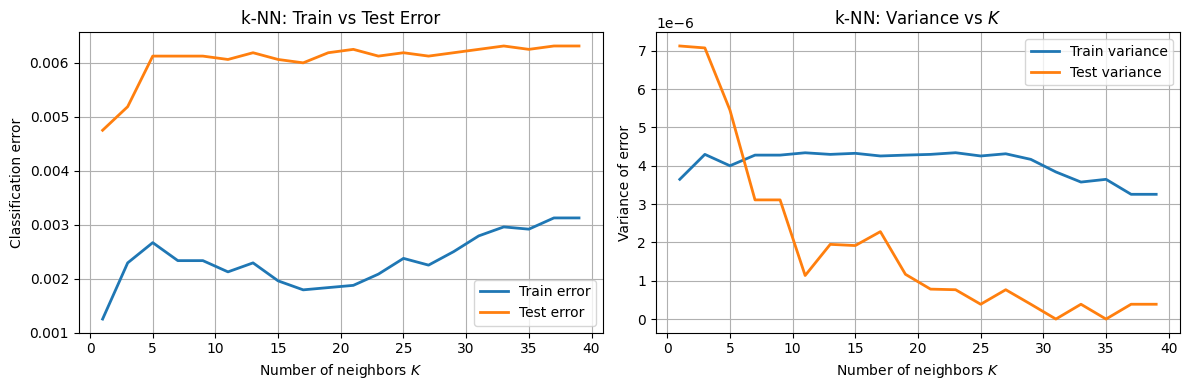

In [ ]:
# ============================================================
# Bias–Variance simulation for k-NN classification
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split

np.random.seed(1)

# ------------------------------------------------------------
# 1) Data-generating process (unknown ground truth)
# ------------------------------------------------------------
n_total = 120

X0 = np.random.multivariate_normal(
    mean=[3, 3],
    cov=[[2.5,1.2],[1.2,2.5]],
    size=n_total // 2
)

X1 = np.random.multivariate_normal(
    mean=[6, 6],
    cov=[[2.5, -1.2], [-1.2, 2.5]],
    size=n_total // 2
)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_total // 2), np.ones(n_total // 2)])

# Fixed train / test split (important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=0
)

# ------------------------------------------------------------
# 2) Monte Carlo setup
# ------------------------------------------------------------
Ks = np.arange(1, 41, 2)      # model flexibility
n_repeats = 100               # resampling of training sets

train_err = np.zeros((len(Ks), n_repeats))
test_err = np.zeros((len(Ks), n_repeats))

# ------------------------------------------------------------
# 3) Repeated bootstrap sampling of the training set
# ------------------------------------------------------------
for r in range(n_repeats):

    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train[idx]
    y_boot = y_train[idx]

    for i, K in enumerate(Ks):
        knn = KNeighborsClassifier(n_neighbors=K)
        knn.fit(X_boot, y_boot)

        train_err[i, r] = zero_one_loss(
            y_train, knn.predict(X_train)
        )
        test_err[i, r] = zero_one_loss(
            y_test, knn.predict(X_test)
        )

# ------------------------------------------------------------
# 4) Aggregate statistics
# ------------------------------------------------------------
mean_train_err = train_err.mean(axis=1)
mean_test_err = test_err.mean(axis=1)

var_train = train_err.var(axis=1)
var_test = test_err.var(axis=1)

# ------------------------------------------------------------
# 5) Plots
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))

# Error curves (bias–variance tradeoff)
plt.subplot(1, 2, 1)
plt.plot(Ks, mean_train_err, label="Train error", linewidth=2)
plt.plot(Ks, mean_test_err, label="Test error", linewidth=2)
plt.xlabel("Number of neighbors $K$")
plt.ylabel("Classification error")
plt.title("k-NN: Train vs Test Error")
plt.legend()
plt.grid(True)

# Variance curves
plt.subplot(1, 2, 2)
plt.plot(Ks, var_train, label="Train variance", linewidth=2)
plt.plot(Ks, var_test, label="Test variance", linewidth=2)
plt.xlabel("Number of neighbors $K$")
plt.ylabel("Variance of error")
plt.title("k-NN: Variance vs $K$")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
